# From Machine Learning to Quantum Machine Learning
## A Hands-On Classification and Regression Workshop

**Quantum Computing Fall Fest — Quantum Machine Learning (QML)**

This notebook develops one complete supervised-learning workflow using the **same dataset** for classical machine learning (ML) and quantum machine learning (QML). We will solve both:

- **Classification:** predict `class_target` (0 or 1)
- **Regression:** predict `regression_target` (a continuous value)

The goal is not to assume that a quantum model is automatically superior. Instead, we will build, run, evaluate, and compare classical and quantum approaches using transparent metrics.

### Learning objectives
By the end, you should be able to:
1. Explain features, targets, training, testing, prediction and generalization.
2. Distinguish classification from regression.
3. Prepare data without leakage and evaluate classical ML models.
4. Explain qubits, superposition, entanglement, measurement and parameterized circuits.
5. Encode classical data into quantum circuits.
6. Build a quantum-kernel classifier and a variational quantum classifier.
7. Build a variational quantum regressor/QNN.
8. Compare ML and QML fairly and discuss practical limitations.


# 0. Before You Begin — Environment Setup

### Required software
- Python 3.10+
- Jupyter Notebook/JupyterLab **or** Google Colab
- `qml_ml_workshop_dataset.csv`
- Internet access for package installation
- IBM Quantum account only for the optional hardware extension

> **Workshop note:** Qiskit APIs evolve. The setup below prints package versions so results are reproducible. If you are using a prepared workshop environment, use the versions supplied by the instructor.


In [1]:
# Run this only if the packages are not already installed.
# In Jupyter/Colab, %pip installs into the active kernel.

%pip install -q numpy pandas matplotlib scipy scikit-learn qiskit qiskit-aer qiskit-machine-learning qiskit-ibm-runtime pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.3/282.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6

In [2]:
# General scientific Python
import sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Classical ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

# Qiskit basics
from qiskit import QuantumCircuit

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

import sklearn, qiskit
print("Scikit-learn:", sklearn.__version__)
print("Qiskit:", qiskit.__version__)
print("\nEnvironment loaded successfully.")

Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Qiskit: 2.5.2

Environment loaded successfully.


## 0.1 Test the quantum installation
A two-qubit Bell-state circuit is a useful sanity check. The Hadamard gate creates superposition and the controlled-X gate correlates the two qubits.

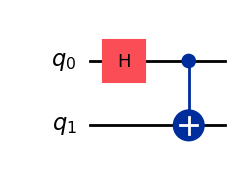

In [3]:
qc_test = QuantumCircuit(2)
qc_test.h(0)
qc_test.cx(0, 1)
qc_test.draw("mpl")

# Part I — Machine Learning Foundations

## 1. What is machine learning?
Traditional programming specifies explicit rules. In supervised machine learning, we instead provide examples containing inputs and known outputs and ask an algorithm to learn a predictive mapping:

\[
\mathbf{x} \longrightarrow f(\mathbf{x};\theta) \longrightarrow \hat y
\]

- **Sample/observation:** one row of data.
- **Feature:** an input variable used for prediction.
- **Target/label:** the quantity we want to predict.
- **Model parameters \(\theta\):** values learned from training data.
- **Training:** adjusting model parameters using known examples.
- **Inference:** using the trained model to predict unseen examples.
- **Generalization:** performing well on data not used during training.

### Classification versus regression
**Classification** predicts categories:
\[
y_{class}\in\{0,1\}.
\]

**Regression** predicts a continuous number:
\[
y_{reg}\in\mathbb{R}.
\]

We will perform both tasks using the same feature matrix \(X\).

## 2. Supervised, unsupervised and reinforcement learning
- **Supervised learning:** learn from labeled examples. This notebook focuses here.
- **Unsupervised learning:** discover structure without target labels, e.g. clustering or dimensionality reduction.
- **Reinforcement learning:** an agent learns actions from rewards and interactions with an environment.

### Check-in
Before running any model, identify which of these are classification and which are regression:
1. Spam/not spam
2. Tomorrow's temperature
3. Stable/unstable material
4. Band gap in eV


# Part II — Load and Understand the Dataset

## 3. Load the CSV
Keep `qml_ml_workshop_dataset.csv` in the same folder as this notebook. If you are in Colab, upload the CSV into the session first.

In [5]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Dataset location
DATA_PATH = "/content/drive/MyDrive/qml_ml_workshop_dataset.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Mounted at /content/drive
Dataset loaded successfully!
Dataset shape: (1200, 13)


,sample_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,noise_feature_1,noise_feature_2,class_target,regression_target
0,QML_0001,0.304717,-0.956566,-0.446069,-2.027223,-0.632695,-0.084990,-0.203599,0.907523,-0.818170,-1.498972,0,4.216589
1,QML_0002,-1.039984,-0.985256,0.980191,-0.759935,-1.063402,0.121038,-0.202555,-0.299380,-0.464004,0.649248,1,4.211821
2,QML_0003,0.750451,0.769941,0.281173,2.261430,1.171062,1.526303,1.360791,1.352436,0.599089,-0.337908,1,6.024525
3,QML_0004,0.940565,0.430273,-0.697557,0.575678,0.594405,0.437518,-0.580519,0.073724,1.143076,-1.871120,1,8.213393
4,QML_0005,-1.951035,-1.626048,-0.865940,-0.592949,-1.221365,0.176293,-0.658734,-1.432268,2.701968,-0.063089,0,3.144366


In [7]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['sample_id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'noise_feature_1', 'noise_feature_2', 'class_target', 'regression_target']

Data types:
sample_id             object
feature_1            float64
feature_2            float64
feature_3            float64
feature_4            float64
feature_5            float64
feature_6            float64
feature_7            float64
feature_8            float64
noise_feature_1      float64
noise_feature_2      float64
class_target           int64
regression_target    float64
dtype: object

Missing values:
sample_id            0
feature_1            0
feature_2            0
feature_3            0
feature_4            0
feature_5            0
feature_6            0
feature_7            0
feature_8            0
noise_feature_1      0
noise_feature_2      0
class_target         0
regression_target    0
dtype: int64

Duplicate rows: 0


## 4. Dataset design
The dataset contains:
- `sample_id`: identifier only — **not a predictor**.
- `feature_1` ... `feature_8`: informative numerical predictors.
- `noise_feature_1`, `noise_feature_2`: nuisance features deliberately included to make the exercise realistic.
- `class_target`: binary classification target.
- `regression_target`: continuous regression target.

The nuisance variables are important pedagogically: real datasets often contain variables that contribute little useful signal.

# Part III — Exploratory Data Analysis (EDA)

## 5. Descriptive statistics
EDA helps us understand the data before fitting models. We inspect scale, variation, class balance, correlations and possible nonlinear relationships.

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
feature_1,1200.0,-0.022238,0.985594,-3.648413,-0.682161,0.003452,0.615438,3.178854
feature_2,1200.0,-0.065665,1.025915,-3.259228,-0.709989,-0.043037,0.635090,3.402336
feature_3,1200.0,0.038389,0.991975,-2.861518,-0.647859,0.026388,0.739402,3.088512
feature_4,1200.0,-0.064227,1.421724,-2.495369,-1.281291,-0.103784,1.130333,2.495200
feature_5,1200.0,-0.032710,0.804748,-1.999811,-0.750793,-0.110355,0.740583,1.625654
feature_6,1200.0,0.022752,1.015130,-3.062868,-0.635995,-0.042544,0.726525,3.293854
feature_7,1200.0,0.001044,0.960275,-3.491439,-0.643152,-0.016907,0.656645,3.253857
feature_8,1200.0,0.000021,0.863223,-1.494826,-0.757034,0.029080,0.715331,1.497178
noise_feature_1,1200.0,-0.013813,1.007556,-3.119475,-0.674338,-0.016373,0.670331,3.126173
noise_feature_2,1200.0,-0.011856,1.010047,-3.082805,-0.681730,-0.023891,0.649753,4.151241


class_target
0    600
1    600
Name: count, dtype: int64


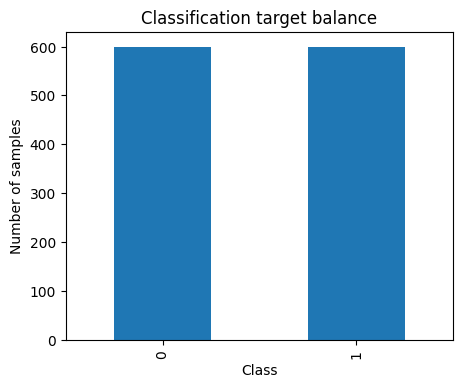

In [9]:
class_counts = df["class_target"].value_counts().sort_index()
print(class_counts)

fig, ax = plt.subplots(figsize=(5,4))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Classification target balance")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
plt.show()

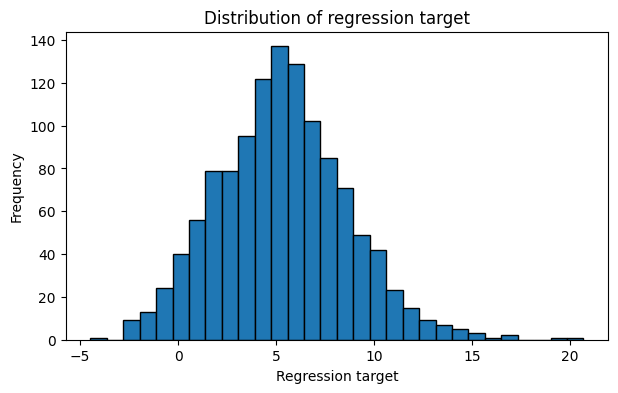

In [10]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(df["regression_target"], bins=30, edgecolor="black")
ax.set_title("Distribution of regression target")
ax.set_xlabel("Regression target")
ax.set_ylabel("Frequency")
plt.show()

## 6. Feature distributions

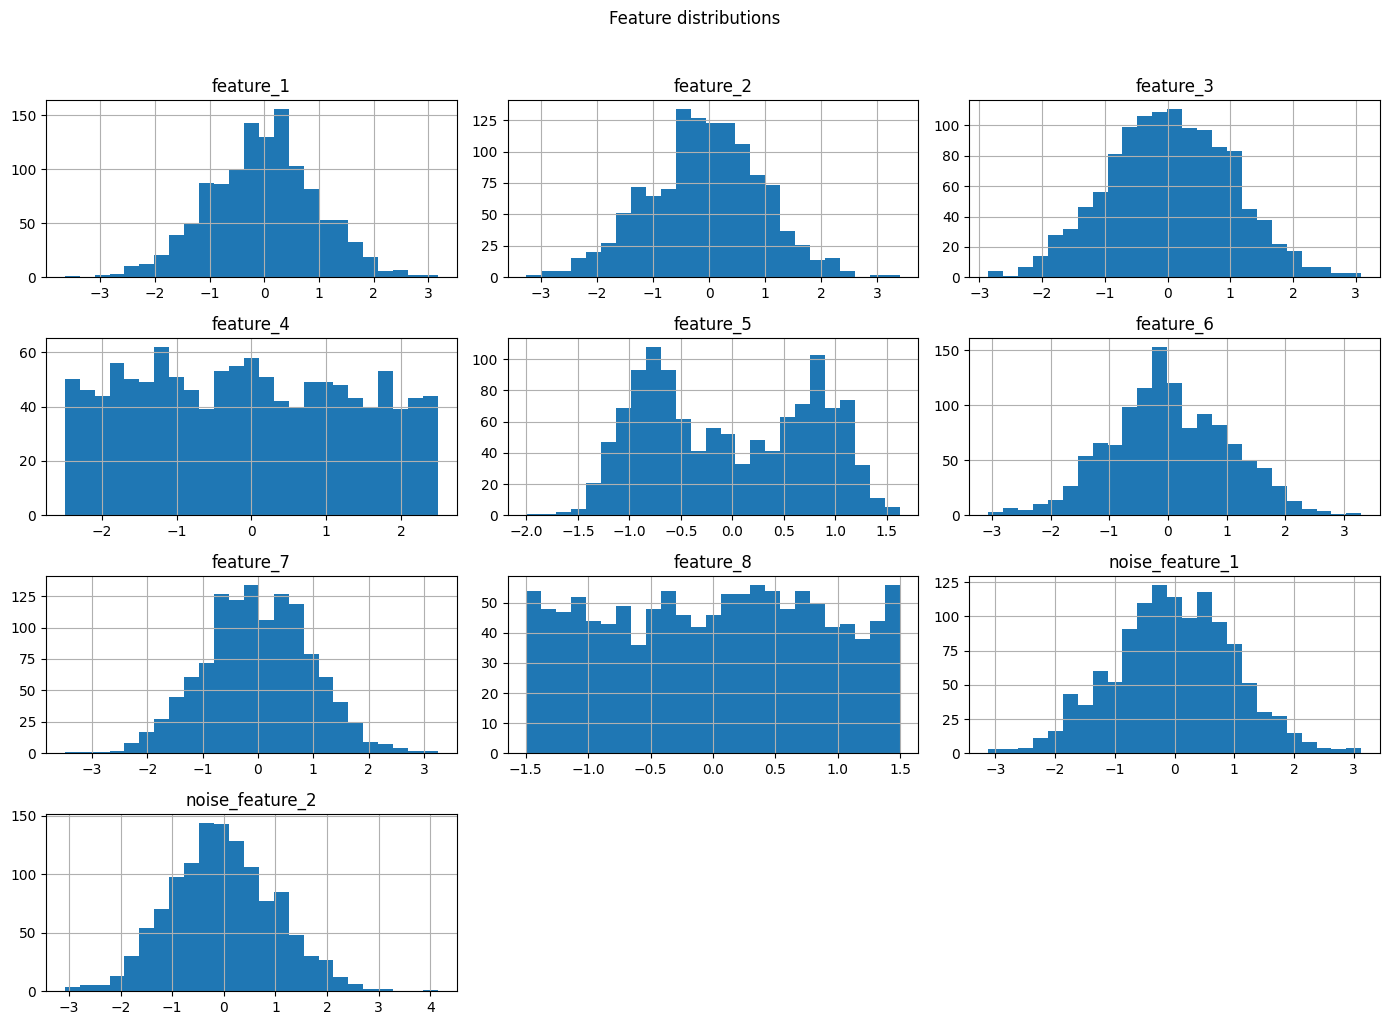

In [11]:
feature_cols = [c for c in df.columns if c.startswith("feature_") or c.startswith("noise_feature_")]

df[feature_cols].hist(figsize=(14,10), bins=25)
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## 7. Correlation analysis
Pearson correlation measures linear association:
\[
\rho_{XY}=\frac{\operatorname{cov}(X,Y)}{\sigma_X\sigma_Y}.
\]
A correlation near zero does **not** prove that two variables are unrelated; the relationship may be nonlinear.

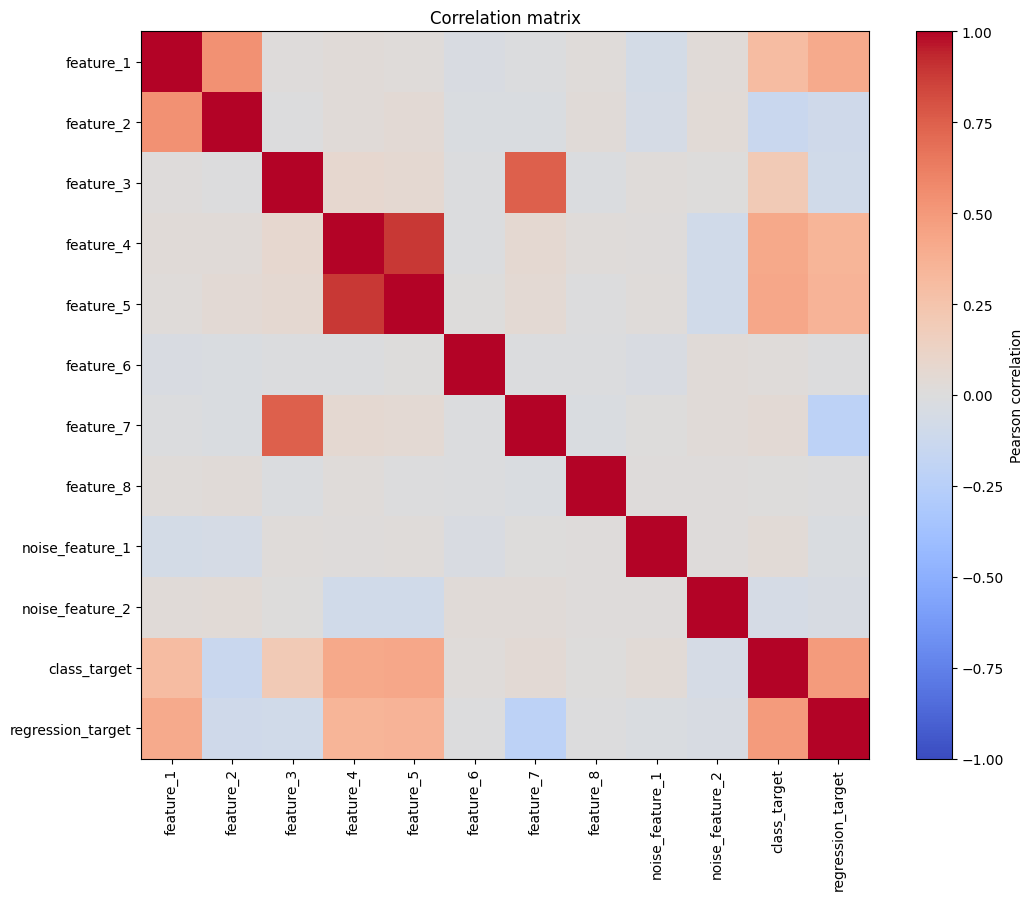

In [12]:
corr_cols = feature_cols + ["class_target", "regression_target"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

# Part IV — Data Preparation

## 8. Define features and targets

In [13]:
X = df[feature_cols].copy()
y_class = df["class_target"].copy()
y_reg = df["regression_target"].copy()

print("X:", X.shape)
print("Classification target:", y_class.shape)
print("Regression target:", y_reg.shape)

X: (1200, 10)
Classification target: (1200,)
Regression target: (1200,)


## 9. Train/test split
We reserve unseen observations for evaluation. For classification we use **stratification** so class proportions are preserved.

\[
D=D_{train}\cup D_{test}, \qquad D_{train}\cap D_{test}=\varnothing.
\]

**Data leakage warning:** preprocessing must be learned from training data only.

In [16]:
# Generate one set of row indices so both tasks use
# exactly the same held-out observations.

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

# ------------------------------------------------------------
# Classification data
# ------------------------------------------------------------

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

yc_train = y_class.iloc[train_idx].copy()
yc_test = y_class.iloc[test_idx].copy()

# ------------------------------------------------------------
# Regression data
# ------------------------------------------------------------

yr_train = y_reg.iloc[train_idx].copy()
yr_test = y_reg.iloc[test_idx].copy()

# ------------------------------------------------------------
# Check the split
# ------------------------------------------------------------

print("Training samples:", len(train_idx))
print("Test samples:", len(test_idx))

print("\nTraining class proportions:")
print(
    yc_train.value_counts(normalize=True)
    .sort_index()
)

print("\nTest class proportions:")
print(
    yc_test.value_counts(normalize=True)
    .sort_index()
)

Training samples: 960
Test samples: 240

Training class proportions:
class_target
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class proportions:
class_target
0    0.5
1    0.5
Name: proportion, dtype: float64


## 10. Standardization
For many models we transform a feature using
\[
z=\frac{x-\mu_{train}}{\sigma_{train}}.
\]
The mean and standard deviation are estimated **only from the training set**. Pipelines make this safer.

# Part V — Classical Machine Learning: Classification

## 11. Evaluation metrics
From true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN):

\[
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
\]
\[
Precision=\frac{TP}{TP+FP},\qquad Recall=\frac{TP}{TP+FN}
\]
\[
F_1=2\frac{Precision\cdot Recall}{Precision+Recall}.
\]

ROC-AUC evaluates ranking across classification thresholds rather than at one fixed threshold.

In [17]:
classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

class_results = []
trained_classifiers = {}

for name, model in classifiers.items():
    t0 = time.perf_counter()
    model.fit(X_train, yc_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    trained_classifiers[name] = model
    class_results.append({
        "Model": name,
        "Type": "Classical",
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred),
        "Recall": recall_score(yc_test, pred),
        "F1": f1_score(yc_test, pred),
        "ROC_AUC": roc_auc_score(yc_test, prob),
        "Train_time_s": elapsed
    })

class_results_df = pd.DataFrame(class_results).sort_values("F1", ascending=False)
display(class_results_df)

,Model,Type,Accuracy,Precision,Recall,F1,ROC_AUC,Train_time_s
1,SVM (RBF),Classical,0.845833,0.837398,0.858333,0.847737,0.930833,0.326750
0,Logistic Regression,Classical,0.829167,0.816000,0.850000,0.832653,0.921042,0.045671
2,Random Forest,Classical,0.812500,0.820513,0.800000,0.810127,0.896215,3.789461


## 12. Confusion matrices

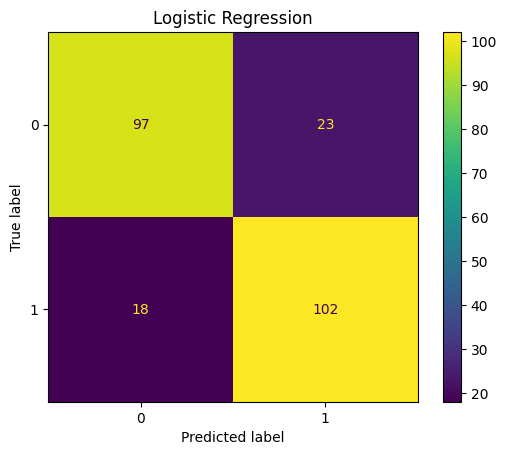

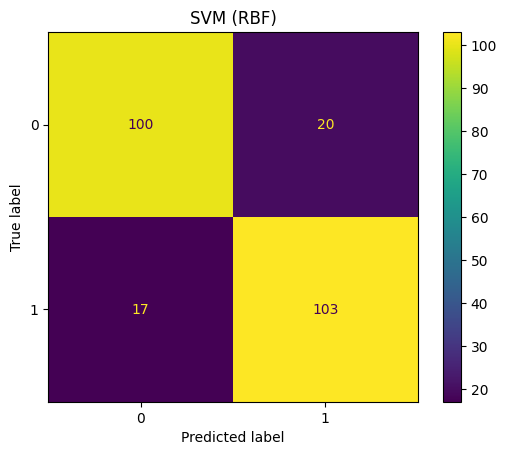

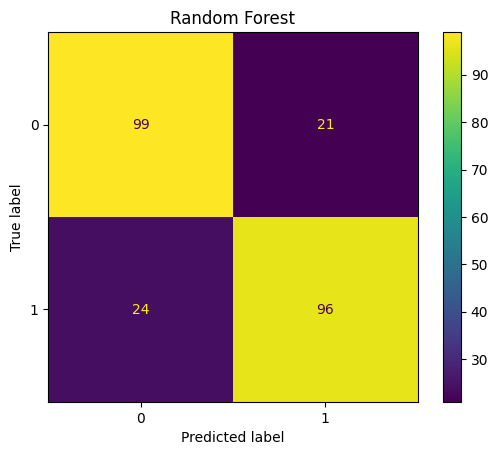

In [18]:
for name, model in trained_classifiers.items():
    pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(yc_test, pred)
    plt.title(name)
    plt.show()

## 13. ROC curves

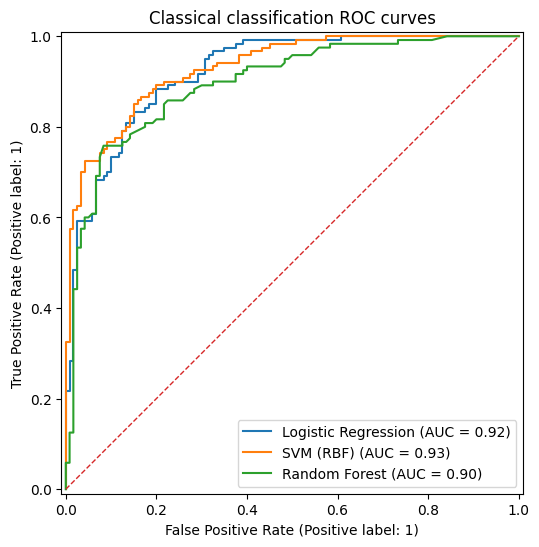

In [19]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in trained_classifiers.items():
    RocCurveDisplay.from_estimator(model, X_test, yc_test, ax=ax, name=name)
ax.plot([0,1],[0,1], "--", linewidth=1)
ax.set_title("Classical classification ROC curves")
plt.show()

## 14. Feature importance — Random Forest
Feature importance is model-specific and should not automatically be interpreted as causality.

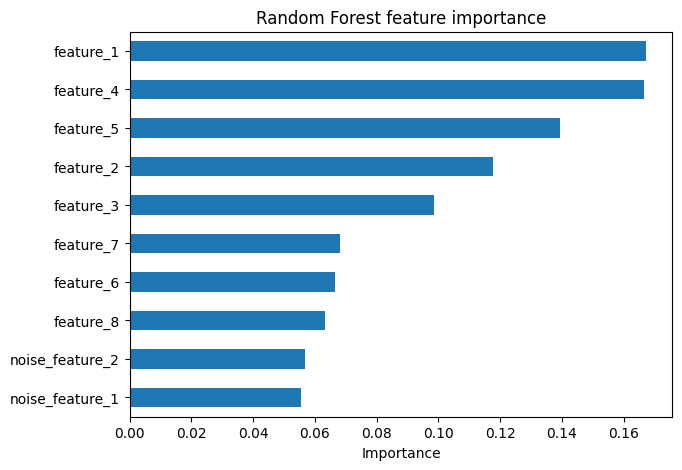

In [20]:
rf = trained_classifiers["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7,5))
importance.plot(kind="barh", ax=ax)
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Importance")
plt.show()

# Part VI — Classical Machine Learning: Regression

## 15. Regression metrics
For true targets \(y_i\) and predictions \(\hat y_i\):

\[
MAE=\frac{1}{N}\sum_i|y_i-\hat y_i|
\]
\[
RMSE=\sqrt{\frac{1}{N}\sum_i(y_i-\hat y_i)^2}
\]
\[
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
\]

Lower MAE/RMSE is better; higher \(R^2\) is better. A negative \(R^2\) is possible on test data.

In [21]:
regressors = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1))
    ]),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

reg_results = []
trained_regressors = {}

for name, model in regressors.items():
    t0 = time.perf_counter()
    model.fit(X_train, yr_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)
    trained_regressors[name] = model
    reg_results.append({
        "Model": name,
        "Type": "Classical",
        "MAE": mean_absolute_error(yr_test, pred),
        "RMSE": np.sqrt(mean_squared_error(yr_test, pred)),
        "R2": r2_score(yr_test, pred),
        "Train_time_s": elapsed
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
display(reg_results_df)

,Model,Type,MAE,RMSE,R2,Train_time_s
1,SVR (RBF),Classical,1.167614,1.486910,0.781790,0.152302
2,Random Forest Regressor,Classical,1.340029,1.694756,0.716522,2.685931
0,Linear Regression,Classical,1.615902,2.126108,0.553855,0.029734


## 16. Predicted versus actual and residuals

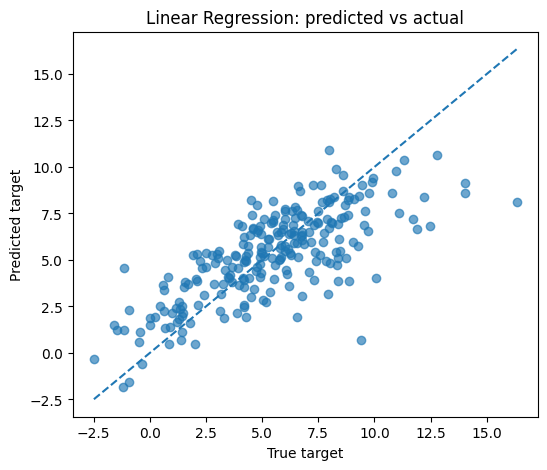

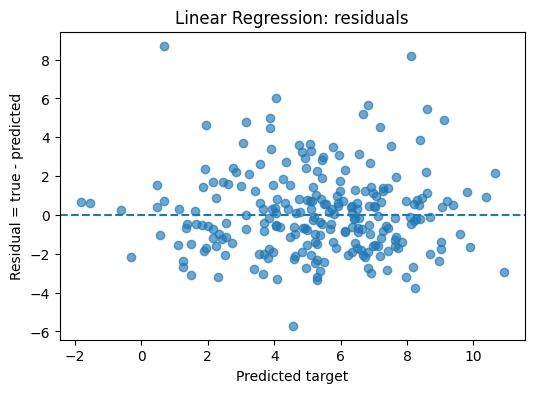

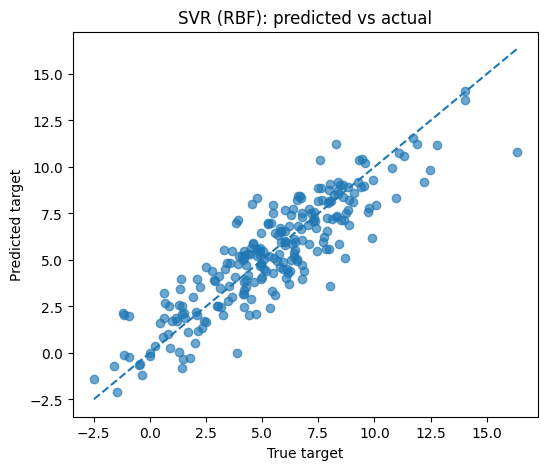

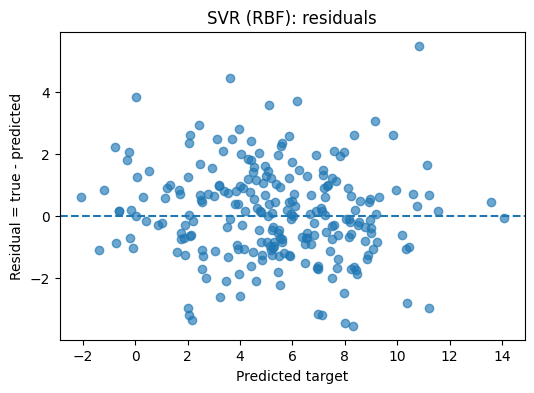

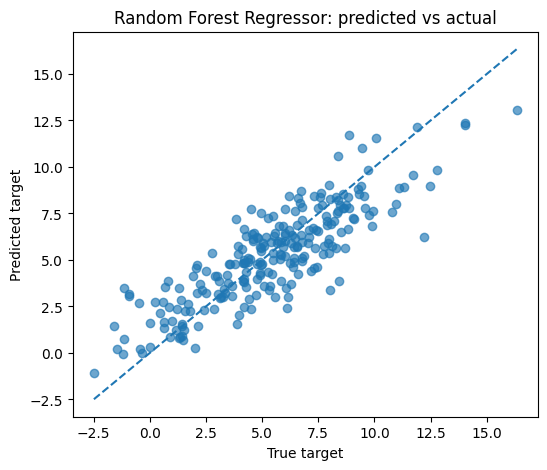

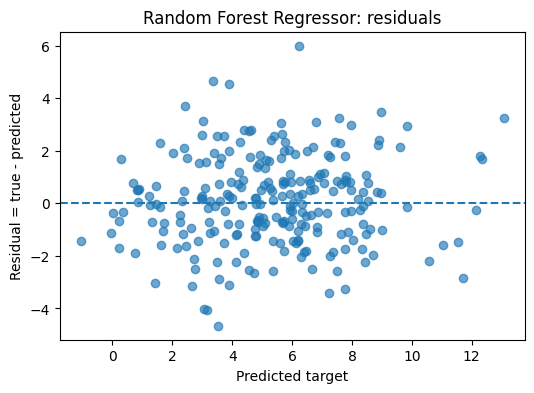

In [22]:
for name, model in trained_regressors.items():
    pred = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(yr_test, pred, alpha=0.65)
    lo = min(yr_test.min(), pred.min())
    hi = max(yr_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "--")
    ax.set_xlabel("True target")
    ax.set_ylabel("Predicted target")
    ax.set_title(name + ": predicted vs actual")
    plt.show()

    residuals = yr_test.to_numpy() - pred
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(pred, residuals, alpha=0.65)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Predicted target")
    ax.set_ylabel("Residual = true - predicted")
    ax.set_title(name + ": residuals")
    plt.show()

# Part VII — From ML to QML

## 17. What changes in quantum machine learning?
A conventional model may be summarized as
\[
X\rightarrow \boxed{\text{classical model}}\rightarrow \hat y.
\]

A common QML workflow is
\[
X\rightarrow \boxed{\text{classical preprocessing}}\rightarrow
\boxed{\text{quantum encoding}}\rightarrow
\boxed{\text{parameterized quantum circuit}}\rightarrow
\boxed{\text{measurement}}\rightarrow \hat y.
\]

Many near-term QML algorithms are **hybrid**: a quantum circuit evaluates a model or kernel while a classical computer handles optimization and orchestration.

> **Important scientific point:** QML does not imply automatic quantum advantage. A fair experiment compares predictive performance, computational resources, dataset size, noise, and model assumptions.

# Part VIII — Quantum Computing Foundations

## 18. Classical bits and qubits
A classical bit is either 0 or 1. A pure qubit can be written
\[
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
\qquad |\alpha|^2+|\beta|^2=1.
\]
Upon computational-basis measurement, the probabilities of 0 and 1 are \(|\alpha|^2\) and \(|\beta|^2\).

### Gates used in this workshop
- \(H\): creates equal superposition from \(|0\rangle\)
- \(X\): bit flip
- \(R_X,R_Y,R_Z\): parameterized rotations
- `CX`: two-qubit entangling gate


Statevector: [0.70710678+0.j 0.70710678+0.j]
Probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


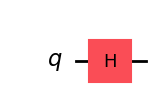

In [23]:
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)
state = Statevector.from_instruction(qc)
print("Statevector:", state.data)
print("Probabilities:", state.probabilities_dict())
qc.draw("mpl")

## 19. Entanglement: Bell state
Starting from \(|00\rangle\), applying \(H\) and then `CX` gives
\[
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt2}.
\]

{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


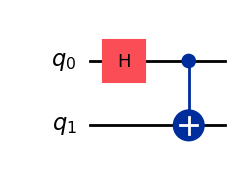

In [24]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
state = Statevector.from_instruction(bell)
print(state.probabilities_dict())
bell.draw("mpl")

# Part IX — Preparing Classical Data for QML

## 20. Why reduce the feature dimension?
Quantum simulation cost grows rapidly with qubit count. A statevector for \(n\) qubits contains \(2^n\) complex amplitudes. For an educational notebook, we therefore reduce the 10-dimensional classical feature space to a small quantum input.

For a fairer direct comparison, we will create a **shared reduced representation** and train both classical and quantum models on it.

Here we use:
1. Standardization
2. PCA to 2 components
3. Min-max scaling to an angular interval suitable for rotation-based encoding

PCA is fitted on training data only.

In [25]:
# Fit preprocessing only on training data.
qml_scaler = StandardScaler()
Xtr_std = qml_scaler.fit_transform(X_train)
Xte_std = qml_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Xtr_pca = pca.fit_transform(Xtr_std)
Xte_pca = pca.transform(Xte_std)

# Scale PCA coordinates to [0, pi] using training data only.
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
Xtr_q = angle_scaler.fit_transform(Xtr_pca)
Xte_q = angle_scaler.transform(Xte_pca)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())
print("Quantum input shapes:", Xtr_q.shape, Xte_q.shape)

Explained variance ratio: [0.20208413 0.16666676]
Total explained variance: 0.3687508895935332
Quantum input shapes: (960, 2) (240, 2)


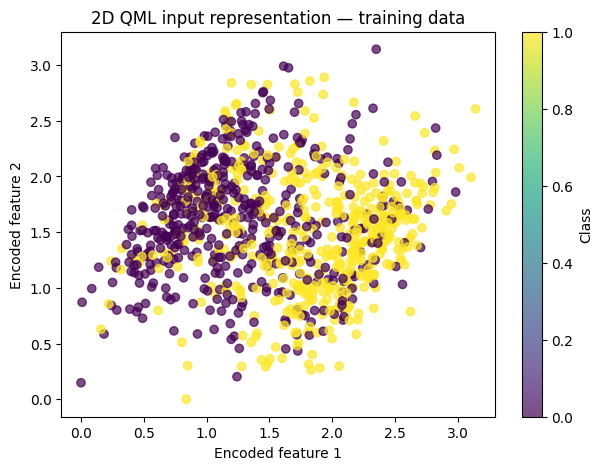

In [26]:
fig, ax = plt.subplots(figsize=(7,5))
scatter = ax.scatter(Xtr_q[:,0], Xtr_q[:,1], c=yc_train, alpha=0.7)
ax.set_xlabel("Encoded feature 1")
ax.set_ylabel("Encoded feature 2")
ax.set_title("2D QML input representation — training data")
plt.colorbar(scatter, ax=ax, label="Class")
plt.show()

## 21. QML training subset
Classical models can train quickly on all 960 training samples. Quantum simulation can be much more expensive, especially for variational optimization. For a live workshop we use a **stratified QML subset**, while retaining the full held-out test set for evaluation.

This is a computational compromise, not a claim that QML needs less data.

In [27]:
QML_TRAIN_SIZE = 160   # reduce further (e.g. 80) if a laptop is slow

qml_sub_idx, _ = train_test_split(
    np.arange(len(Xtr_q)),
    train_size=QML_TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=yc_train
)

Xq_train = Xtr_q[qml_sub_idx]
yq_class_train = yc_train.to_numpy()[qml_sub_idx]
yq_reg_train = yr_train.to_numpy()[qml_sub_idx]

print("QML training subset:", Xq_train.shape)
print("Class counts:", np.bincount(yq_class_train))

QML training subset: (160, 2)
Class counts: [80 80]


## 22. Classical baselines on the SAME 2D representation
This matters. Comparing a 10-feature classical model with a 2-qubit quantum model confounds **model type** with **information content**. We therefore also train reduced classical baselines on the exact same 2D inputs.

In [28]:
reduced_svc = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
reduced_svc.fit(Xq_train, yq_class_train)
red_pred = reduced_svc.predict(Xte_q)
red_prob = reduced_svc.predict_proba(Xte_q)[:,1]

reduced_svr = SVR(kernel="rbf", C=10.0)
reduced_svr.fit(Xq_train, yq_reg_train)
red_reg_pred = reduced_svr.predict(Xte_q)

print("Reduced SVC accuracy:", accuracy_score(yc_test, red_pred))
print("Reduced SVC F1:", f1_score(yc_test, red_pred))
print("Reduced SVR RMSE:", np.sqrt(mean_squared_error(yr_test, red_reg_pred)))
print("Reduced SVR R2:", r2_score(yr_test, red_reg_pred))

Reduced SVC accuracy: 0.6875
Reduced SVC F1: 0.7058823529411765
Reduced SVR RMSE: 2.751611964895138
Reduced SVR R2: 0.25272578787646693


# Part X — Quantum Data Encoding

## 23. Angle encoding
A simple encoding maps a real feature to a rotation angle. For two features:
\[
|\phi(x)\rangle = R_Y(x_1)\otimes R_Y(x_2)|00\rangle
\]
possibly followed by entangling operations.

Qiskit also provides feature-map circuits. A common choice for quantum-kernel demonstrations is the **ZZ feature map**, which combines single-qubit data-dependent rotations with entangling terms.

Feature-map parameters: 2


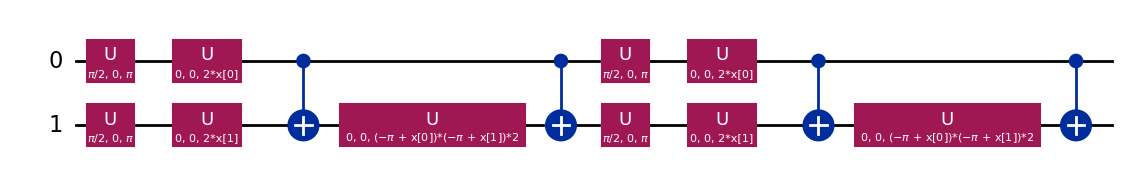

In [29]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement="linear")
print("Feature-map parameters:", feature_map.num_parameters)
feature_map.decompose().draw("mpl")

# Part XI — Quantum Classification I: Quantum Kernel

## 24. Kernel idea
A kernel measures similarity between data points. A quantum feature map sends \(x\) to \(|\phi(x)\rangle\). One fidelity-based kernel is
\[
K(x_i,x_j)=|\langle\phi(x_i)|\phi(x_j)\rangle|^2.
\]
The resulting kernel matrix can be supplied to a support-vector classifier.

This is conceptually useful because we can compare a classical SVM kernel with a quantum-generated kernel.

In [30]:
# Qiskit Machine Learning imports
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)
t0 = time.perf_counter()
qsvc.fit(Xq_train, yq_class_train)
qsvc_time = time.perf_counter() - t0

qsvc_pred = qsvc.predict(Xte_q)

qsvc_metrics = {
    "Model": "QSVC (quantum kernel)",
    "Type": "Quantum",
    "Accuracy": accuracy_score(yc_test, qsvc_pred),
    "Precision": precision_score(yc_test, qsvc_pred),
    "Recall": recall_score(yc_test, qsvc_pred),
    "F1": f1_score(yc_test, qsvc_pred),
    "ROC_AUC": np.nan,  # not computed here because this QSVC setup does not expose calibrated probabilities
    "Train_time_s": qsvc_time
}
qsvc_metrics

{'Model': 'QSVC (quantum kernel)',
 'Type': 'Quantum',
 'Accuracy': 0.5166666666666667,
 'Precision': 0.5172413793103449,
 'Recall': 0.5,
 'F1': 0.5084745762711864,
 'ROC_AUC': nan,
 'Train_time_s': 54.51118355699964}

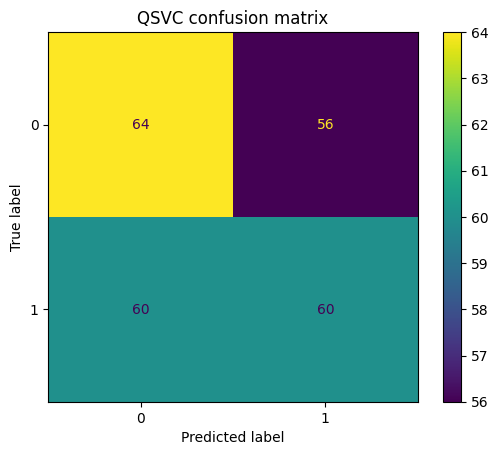

In [31]:
ConfusionMatrixDisplay.from_predictions(yc_test, qsvc_pred)
plt.title("QSVC confusion matrix")
plt.show()

## 25. Inspect a small quantum kernel matrix
The diagonal should be close to 1 because every encoded state has maximal fidelity with itself.

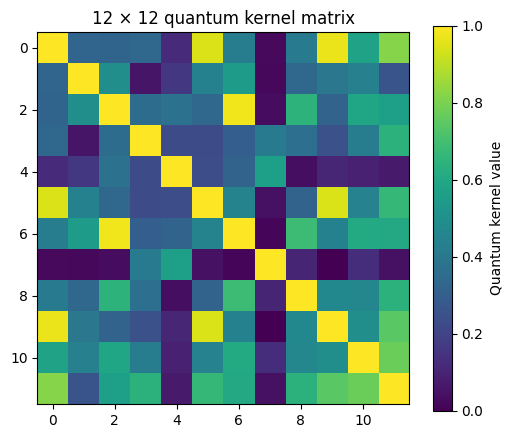

In [32]:
K_demo = quantum_kernel.evaluate(Xq_train[:12])
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(K_demo, vmin=0, vmax=1, cmap="viridis")
fig.colorbar(im, ax=ax, label="Quantum kernel value")
ax.set_title("12 × 12 quantum kernel matrix")
plt.show()

# Part XII — Quantum Classification II: Variational Quantum Classifier

## 26. Variational model
A common variational classifier has the structure
\[
f_\theta(x)=\langle 0|U_\phi^\dagger(x)W^\dagger(\theta)\,O\,W(\theta)U_\phi(x)|0\rangle.
\]

- \(U_\phi(x)\): data encoding / feature map
- \(W(\theta)\): trainable ansatz
- \(O\): measured observable or equivalent output rule
- \(\theta\): parameters updated by a classical optimizer

The loop is hybrid:
\[
\theta\rightarrow \text{quantum evaluation}\rightarrow \text{loss}\rightarrow
\text{classical optimizer}\rightarrow\theta'.
\]

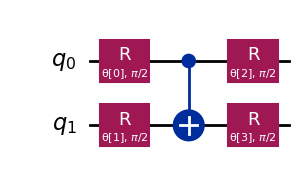

In [33]:
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import COBYLA

ansatz = real_amplitudes(num_qubits=2, reps=1, entanglement="linear")
ansatz.decompose().draw("mpl")

In [34]:
vqc_history = []

def vqc_callback(weights, objective_value):
    vqc_history.append(float(objective_value))

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=60),
    callback=vqc_callback
)

t0 = time.perf_counter()
vqc.fit(Xq_train, yq_class_train)
vqc_time = time.perf_counter() - t0

vqc_pred = np.asarray(vqc.predict(Xte_q)).astype(int).ravel()

vqc_metrics = {
    "Model": "VQC",
    "Type": "Quantum",
    "Accuracy": accuracy_score(yc_test, vqc_pred),
    "Precision": precision_score(yc_test, vqc_pred),
    "Recall": recall_score(yc_test, vqc_pred),
    "F1": f1_score(yc_test, vqc_pred),
    "ROC_AUC": np.nan,
    "Train_time_s": vqc_time
}
vqc_metrics

{'Model': 'VQC',
 'Type': 'Quantum',
 'Accuracy': 0.5166666666666667,
 'Precision': 0.5123456790123457,
 'Recall': 0.6916666666666667,
 'F1': 0.5886524822695035,
 'ROC_AUC': nan,
 'Train_time_s': 16.91496379099999}

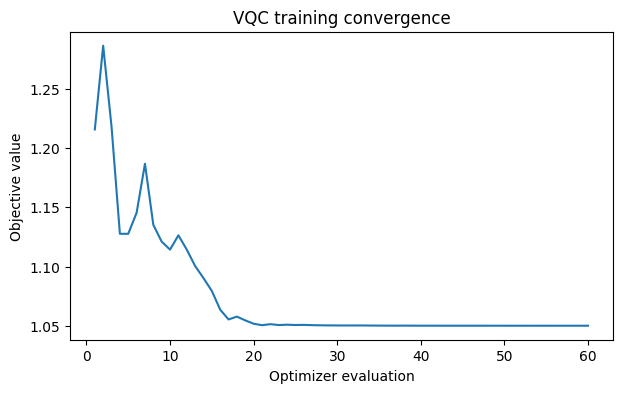

In [35]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(vqc_history)+1), vqc_history)
ax.set_xlabel("Optimizer evaluation")
ax.set_ylabel("Objective value")
ax.set_title("VQC training convergence")
plt.show()

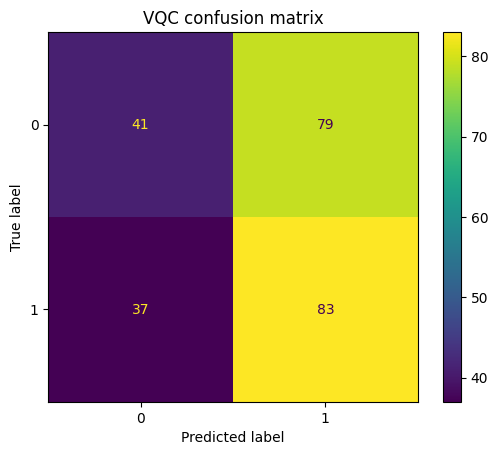

In [36]:
ConfusionMatrixDisplay.from_predictions(yc_test, vqc_pred)
plt.title("VQC confusion matrix")
plt.show()

# Part XIII — Quantum Regression with a Variational QNN

## 27. From classification to regression
For regression, the circuit output is interpreted as a continuous numerical prediction rather than a class label. An expectation-value model can take the form
\[
\hat y=f_\theta(x)=\langle\psi(x,\theta)|O|\psi(x,\theta)\rangle.
\]

Expectation values often occupy a bounded range, so we scale the training regression target to \([-1,1]\), train the quantum model, then transform predictions back to the original target units.

In [37]:
# Scale regression target using TRAINING values only.
reg_target_scaler = MinMaxScaler(feature_range=(-1, 1))
yr_train_scaled_all = reg_target_scaler.fit_transform(yr_train.to_numpy().reshape(-1,1)).ravel()
yq_reg_scaled = yr_train_scaled_all[qml_sub_idx]

print("Scaled QML regression target range:", yq_reg_scaled.min(), yq_reg_scaled.max())

Scaled QML regression target range: -0.8033652021513897 0.47927055798778695


## 28. EstimatorQNN
We combine a feature map and ansatz into one parameterized circuit. The QNN treats the feature-map parameters as **inputs** and the ansatz parameters as **trainable weights**.

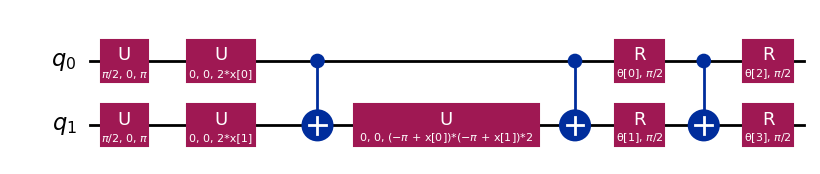

In [38]:
from qiskit.circuit import QuantumCircuit
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor

qnn_feature_map = zz_feature_map(feature_dimension=2, reps=1, entanglement="linear")
qnn_ansatz = real_amplitudes(num_qubits=2, reps=1, entanglement="linear")

qnn_circuit = QuantumCircuit(2)
qnn_circuit.compose(qnn_feature_map, inplace=True)
qnn_circuit.compose(qnn_ansatz, inplace=True)
qnn_circuit.decompose().draw("mpl")

In [39]:
qnn = EstimatorQNN(
    circuit=qnn_circuit,
    input_params=qnn_feature_map.parameters,
    weight_params=qnn_ansatz.parameters,
    input_gradients=False
)

qreg_history = []

def qreg_callback(weights, objective_value):
    qreg_history.append(float(objective_value))

qreg = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",
    optimizer=COBYLA(maxiter=60),
    callback=qreg_callback
)

t0 = time.perf_counter()
qreg.fit(Xq_train, yq_reg_scaled)
qreg_time = time.perf_counter() - t0

qreg_pred_scaled = np.asarray(qreg.predict(Xte_q)).reshape(-1,1)
qreg_pred = reg_target_scaler.inverse_transform(qreg_pred_scaled).ravel()

qreg_metrics = {
    "Model": "Variational QNN Regressor",
    "Type": "Quantum",
    "MAE": mean_absolute_error(yr_test, qreg_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, qreg_pred)),
    "R2": r2_score(yr_test, qreg_pred),
    "Train_time_s": qreg_time
}
qreg_metrics

{'Model': 'Variational QNN Regressor',
 'Type': 'Quantum',
 'MAE': 3.0099551123719115,
 'RMSE': np.float64(3.8412915816616593),
 'R2': -0.45633124038934003,
 'Train_time_s': 10.903520735999791}

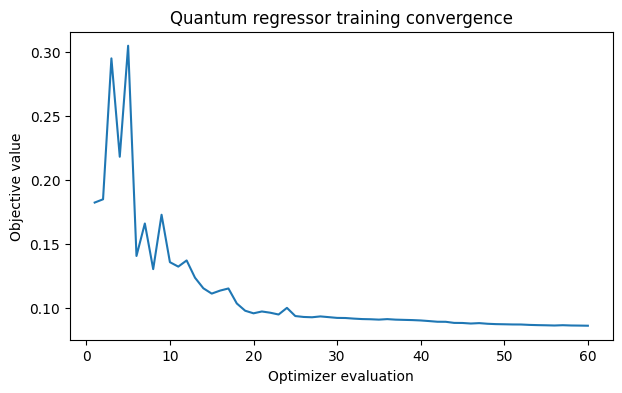

In [40]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(qreg_history)+1), qreg_history)
ax.set_xlabel("Optimizer evaluation")
ax.set_ylabel("Objective value")
ax.set_title("Quantum regressor training convergence")
plt.show()

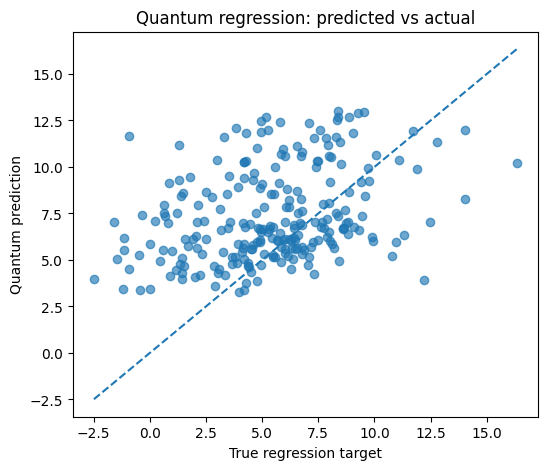

In [41]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(yr_test, qreg_pred, alpha=0.65)
lo = min(yr_test.min(), qreg_pred.min())
hi = max(yr_test.max(), qreg_pred.max())
ax.plot([lo, hi], [lo, hi], "--")
ax.set_xlabel("True regression target")
ax.set_ylabel("Quantum prediction")
ax.set_title("Quantum regression: predicted vs actual")
plt.show()

# Part XIV — ML versus QML Comparison

## 29. Two comparisons are useful
### A. Full-feature classical benchmark
This answers: *How well do ordinary classical methods solve the original problem?*

### B. Reduced-representation comparison
This answers a fairer modeling question: *What happens when classical and quantum methods receive the same two-dimensional information and QML training subset?*

Do not interpret a difference between a 10-feature classical model and a 2-qubit model as evidence for or against quantum advantage by itself.

In [42]:
# Add reduced classical classification baseline
reduced_class_row = {
    "Model": "SVC — same 2D QML data",
    "Type": "Classical (reduced)",
    "Accuracy": accuracy_score(yc_test, red_pred),
    "Precision": precision_score(yc_test, red_pred),
    "Recall": recall_score(yc_test, red_pred),
    "F1": f1_score(yc_test, red_pred),
    "ROC_AUC": roc_auc_score(yc_test, red_prob),
    "Train_time_s": np.nan
}

classification_comparison = pd.concat([
    class_results_df,
    pd.DataFrame([reduced_class_row, qsvc_metrics, vqc_metrics])
], ignore_index=True)

display(classification_comparison.sort_values("F1", ascending=False))

,Model,Type,Accuracy,Precision,Recall,F1,ROC_AUC,Train_time_s
0,SVM (RBF),Classical,0.845833,0.837398,0.858333,0.847737,0.930833,0.326750
1,Logistic Regression,Classical,0.829167,0.816000,0.850000,0.832653,0.921042,0.045671
2,Random Forest,Classical,0.812500,0.820513,0.800000,0.810127,0.896215,3.789461
3,SVC — same 2D QML data,Classical (reduced),0.687500,0.666667,0.750000,0.705882,0.729931,NaN
5,VQC,Quantum,0.516667,0.512346,0.691667,0.588652,NaN,16.914964
4,QSVC (quantum kernel),Quantum,0.516667,0.517241,0.500000,0.508475,NaN,54.511184


In [43]:
reduced_reg_row = {
    "Model": "SVR — same 2D QML data",
    "Type": "Classical (reduced)",
    "MAE": mean_absolute_error(yr_test, red_reg_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, red_reg_pred)),
    "R2": r2_score(yr_test, red_reg_pred),
    "Train_time_s": np.nan
}

regression_comparison = pd.concat([
    reg_results_df,
    pd.DataFrame([reduced_reg_row, qreg_metrics])
], ignore_index=True)

display(regression_comparison.sort_values("RMSE"))

,Model,Type,MAE,RMSE,R2,Train_time_s
0,SVR (RBF),Classical,1.167614,1.486910,0.781790,0.152302
1,Random Forest Regressor,Classical,1.340029,1.694756,0.716522,2.685931
2,Linear Regression,Classical,1.615902,2.126108,0.553855,0.029734
3,SVR — same 2D QML data,Classical (reduced),2.182223,2.751612,0.252726,NaN
4,Variational QNN Regressor,Quantum,3.009955,3.841292,-0.456331,10.903521


## 30. Interpretation questions
Do not stop at “which accuracy is highest?” Discuss:
1. Did PCA remove useful information?
2. Were all models trained on the same number of observations?
3. How much longer did quantum simulation take?
4. Did the variational objective converge?
5. Is the test set large enough for a stable conclusion?
6. How sensitive are QML results to circuit architecture and optimizer?
7. Would noisy hardware change the conclusion?
8. Are we comparing predictive utility, computational efficiency, or both?


# Part XV — Measurement Shots and Noise

## 31. Finite-shot estimation
Quantum hardware returns samples from repeated measurements. If outcome 1 occurs \(n_1\) times in \(N\) shots,
\[
\hat p(1)=\frac{n_1}{N}.
\]
Finite shots introduce sampling uncertainty. Increasing shots reduces this uncertainty but increases execution cost.

In [44]:
from qiskit_aer import AerSimulator
from qiskit import transpile

meas = QuantumCircuit(1,1)
meas.h(0)
meas.measure(0,0)
sim = AerSimulator()

for shots in [100, 1000, 10000]:
    tqc = transpile(meas, sim)
    counts = sim.run(tqc, shots=shots, seed_simulator=RANDOM_STATE).result().get_counts()
    p1 = counts.get("1",0)/shots
    print(f"shots={shots:5d}  counts={counts}  estimated P(1)={p1:.4f}")

shots=  100  counts={'1': 51, '0': 49}  estimated P(1)=0.5100
shots= 1000  counts={'1': 486, '0': 514}  estimated P(1)=0.4860
shots=10000  counts={'0': 4921, '1': 5079}  estimated P(1)=0.5079


## 32. Noise
Real devices are affected by gate errors, readout errors, decoherence and connectivity constraints. Consequently, simulator results should not automatically be interpreted as hardware performance.

For a live event, a good strategy is:
1. Train and debug on a simulator.
2. Select a small representative circuit.
3. Transpile it for a real backend.
4. Run it with a manageable number of shots.
5. Compare hardware measurements with ideal simulation.

Full variational training on shared hardware can be impractical during a workshop because queue time and repeated circuit evaluations can dominate.

# Part XVI — Optional IBM Quantum Hardware Extension

The exact account/channel/backend workflow can change with IBM Quantum service updates. Keep this section optional and confirm it against the workshop's current IBM Quantum instructions before the event.

The conceptual workflow is:
\[
\text{circuit}\rightarrow\text{transpile for backend}\rightarrow\text{execute}\rightarrow\text{measure}\rightarrow\text{post-process}.
\]

For the workshop, use a small circuit rather than attempting to retrain every QML model on hardware.

In [45]:
# OPTIONAL TEMPLATE — intentionally not executed automatically.
# Confirm current IBM Quantum Runtime/API instructions before the event.
#
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService()
# backend = service.least_busy(operational=True, simulator=False)
# print(backend)
#
# Then transpile a SMALL circuit for the selected backend and execute it
# using the currently supported primitive/workflow for your account.

print("Optional hardware section: see instructor guidance before running.")

Optional hardware section: see instructor guidance before running.


# Part XVII — Participant Challenges

## Challenge 1 — Feature dimension
Repeat the shared preprocessing with 2, 3 and 4 PCA components. How do predictive performance and quantum simulation time change?

## Challenge 2 — QML training size
Try \(N=40,80,160,320\) where computationally feasible. Plot performance versus training-set size.

## Challenge 3 — Circuit depth
Change `reps` in the feature map or ansatz. Does a deeper circuit always improve generalization?

## Challenge 4 — Optimizer
Change the variational optimizer and/or iteration budget. Compare convergence curves.

## Challenge 5 — Noise features
Remove `noise_feature_1` and `noise_feature_2`. What changes in classical performance and PCA?

## Challenge 6 — Classical versus quantum kernel
Compare an RBF SVM with QSVC using the exact same reduced training samples.

## Challenge 7 — Regression
Try a different target-scaling interval or QNN architecture. Does RMSE improve? Does optimization become less stable?

## Challenge 8 — Reproducibility
Change the random seed. Which results change, and why?


## 33. Optional learning-curve scaffold
Complete the loop below for a classical model first. Then adapt it to a quantum model if time permits.

In [46]:
# Example scaffold
# sizes = [40, 80, 160, 320]
# scores = []
# for n in sizes:
#     sub_idx, _ = train_test_split(
#         np.arange(len(Xtr_q)), train_size=n,
#         random_state=RANDOM_STATE, stratify=yc_train
#     )
#     model = SVC(kernel="rbf")
#     model.fit(Xtr_q[sub_idx], yc_train.to_numpy()[sub_idx])
#     scores.append(accuracy_score(yc_test, model.predict(Xte_q)))
#
# plt.plot(sizes, scores, marker="o")
# plt.xlabel("Training samples")
# plt.ylabel("Test accuracy")
# plt.show()

# Part XVIII — Scientific Interpretation and Limitations

## 34. What can we conclude?
A responsible conclusion distinguishes **observed results in this experiment** from broad claims about QML.

### If a classical model performs better
Possible reasons include:
- the dataset is small and classically tractable;
- dimensionality reduction discarded information;
- the chosen quantum feature map/ansatz is not well matched to the problem;
- variational optimization did not converge well;
- quantum simulation adds substantial computational overhead.

### If a quantum model performs better
That result is interesting, but it does **not by itself establish quantum advantage**. Check:
- identical training/test observations;
- identical information content/features;
- hyperparameter tuning effort;
- statistical variability across seeds;
- computational resources and wall time;
- performance against strong classical baselines.

### Limitations of this workshop experiment
- synthetic rather than domain-measured data;
- small number of qubits;
- PCA/reduced representation for QML feasibility;
- simulator-dominated quantum execution;
- limited optimizer search;
- single train/test split unless participants extend it;
- no claim of practical quantum advantage.


# Part XIX — Final Take-Home Summary

### Classical supervised ML
\[
X\rightarrow \boxed{\text{classical model}}\rightarrow \hat y
\]

### Variational QML
\[
X\rightarrow \boxed{U_\phi(X)}\rightarrow
\boxed{W(\theta)}\rightarrow
\boxed{\text{measurement}}\rightarrow \hat y
\]
with a classical optimizer updating \(\theta\).

### Quantum kernel ML
\[
X\rightarrow |\phi(X)\rangle\rightarrow
K(x_i,x_j)\rightarrow \boxed{\text{classical kernel method}}.
\]

### The central lesson
QML is not simply “ML, but faster.” It introduces quantum representations and quantum circuit evaluations into learning workflows. Whether that is useful depends on the problem, data representation, circuit design, optimization, hardware/noise, and the strength of the classical baseline.

**A good QML experiment asks a scientific question and measures the answer — it does not assume the answer in advance.**


# Appendix A — Save Workshop Results
The following cells export the comparison tables after the models have been run.

In [ ]:
classification_comparison.to_csv("classification_comparison_results.csv", index=False)
regression_comparison.to_csv("regression_comparison_results.csv", index=False)
print("Saved classification_comparison_results.csv")
print("Saved regression_comparison_results.csv")

# Appendix B — Presenter Discussion Prompts
Use these between sections to keep the workshop interactive:

1. Why do we need a test set?
2. Why must preprocessing be fitted on training data only?
3. Why can accuracy be misleading on imbalanced data?
4. What information is lost when we reduce 10 features to 2 PCs?
5. What exactly does the quantum feature map do?
6. Which part of a VQC is quantum and which part is classical?
7. Why can increasing circuit depth make training harder?
8. Why does finite-shot measurement create uncertainty?
9. What would constitute stronger evidence for a QML benefit?
10. Why is one successful dataset insufficient to claim quantum advantage?
